# Sales Performance Analysis

## Introduction

This project analyzes sales transactions from the Olist Brazilian E-commerce dataset to evaluate business performance across customers, products, and orders. The analysis uses Pandas for data cleaning, data integration, and exploratory data analysis to identify sales trends and generate business insights that can support strategic decision-making.

## Business Problem

Businesses require a clear understanding of their sales performance to identify revenue drivers, monitor customer purchasing behavior, and evaluate product demand. Without proper analysis, it becomes difficult to determine which products, customer segments, and time periods contribute most to business performance. This project analyzes historical sales data to uncover patterns that can support data-driven business decisions.

## Objectives

The objectives of this analysis are to:

- Examine overall sales performance.
- Identify the products that generate the highest sales.
- Determine which product categories contribute the most revenue.
- Analyze customer purchasing patterns.
- Examine monthly sales trends.
- Evaluate geographic sales distribution.
- Generate business insights and recommendations for improving sales performance.

In [1]:
import pandas as pd

In [2]:
# The dataset comes with other tables, we will be loading about 5 datasets from the whole zip, here are the datasets 
# Each file dataset was assigned a variable matching the contents
# Each will also be inspect seprately


customers = pd.read_csv("olist_customers_dataset.csv")

orders = pd.read_csv("olist_orders_dataset.csv")

order_items = pd.read_csv("olist_order_items_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

translation = pd.read_csv("product_category_name_translation.csv")

### Data Inspection 

#### Customers

In [6]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
customers.shape

customers.info()

In [ ]:
customers.isnull().sum()

In [29]:
customers.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [28]:
customers.duplicated().sum()

np.int64(0)

### Data Cleaning (Customers)

##### Customers Dataset Cleaning Summary

The Customers dataset was examined for data quality issues.

- No missing values were found.
- No duplicate records were identified.
- All columns have appropriate data types.
- The customer state values use official Brazilian state abbreviations and require no modification.

Therefore, no cleaning operations were required, and the dataset is ready for merging with the other tables.The dataset contains appropriate data types for all columns. Customer identifiers are stored as text, while the ZIP code prefix is stored as an integer. No data type conversion is required.

#### Orders

In [30]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.shape

In [ ]:
orders.info()

In [56]:
orders.duplicated().sum()

np.int64(0)

In [ ]:
orders.describe()

In [59]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

### Data Cleaning (Orders)

In [60]:
# The date column came as object but we need to convert into panda datetime for accurate analysis 


#Store each column that consist datetime values into date_columns variable
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

#iterate over col(date_column) & assigned panda datetime into every iteration (our conversion happened here)
for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])


##### Orders Dataset Cleaning Summary

The Orders dataset was assessed for data quality.

- No duplicate records were found.
- Five date columns were converted from text (`object`) to `datetime`.
- Missing values were identified in the order approval and delivery date columns. These missing values are expected because some orders were canceled, unavailable, or had not progressed through the delivery process.
- Since the missing values reflect legitimate business events rather than data quality issues, no rows were removed and no missing values were imputed. The dataset is therefore considered clean and ready for analysis.

#### Order_items

In [65]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [41]:
order_items.shape

(112650, 7)

In [67]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [37]:
order_items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [36]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [35]:
order_items.duplicated().sum()

np.int64(0)

### Data Cleaning (Order_items)

In [66]:
#changing the date from default as object to real pandas datetime for easier analysis
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])

##### Order Items Dataset Cleaning Summary

The Order Items dataset was assessed for data quality.

- No missing values were found.
- No duplicate records were identified.
- The `shipping_limit_date` column was converted from text (`object`) to `datetime`.
- The numerical columns (`price` and `freight_value`) were already stored using appropriate numeric data types.
- No additional cleaning was required.

The dataset is clean and ready for merging.

#### Products

In [68]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [43]:
products.shape

(32951, 9)

In [69]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
products.describe()

In [46]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [47]:
products.duplicated().sum()

np.int64(0)

### Data Cleaning (Product)

In [ ]:
products[products["product_category_name"].isnull()]

In [ ]:
products[products["product_weight_g"].isnull()]

In [ ]:
products[products["product_category_name"].isnull()]

In [ ]:
products[products["product_weight_g"].isnull()]

##### Products Dataset Cleaning Summary

The Products dataset was examined for data quality.

- No duplicate records were identified.
- Missing values were found in the product description-related columns (`product_category_name`, `product_name_lenght`, `product_description_lenght`, and `product_photos_qty`) for 610 products.
- Two products were also missing physical measurements such as weight and dimensions.
- These missing values were retained because the affected products may still be associated with valid customer orders. Since the missing information represents unavailable product metadata rather than incorrect values, no rows were removed and no missing values were imputed.

 The Products dataset is considered suitable for merging and subsequent sales analysis.

#### Translation

In [48]:
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [49]:
translation.shape

(71, 2)

In [50]:
translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [51]:
translation.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [52]:
translation.duplicated().sum()

np.int64(0)

In [53]:
translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

### Data Cleaning (Translation)

##### Translation Dataset Cleaning Summary

The Translation dataset was examined for data quality.

- No missing values were found.
- No duplicate records were identified.
- Both columns have appropriate text (`object`) data types.
- Each Portuguese product category has a unique English translation.

No cleaning operations were required, and the dataset is ready to be merged with the Products dataset.

## Merging all Datasets

In [3]:
#inner join both customer table and orders table using the only cusomer_id column that match & exist in both table
customer_orders = pd.merge(
    customers,
    orders,
    on="customer_id",
    how="inner"
)


# Confirm the head, the first 5 to see if dataset added
customer_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00


In [5]:
# there are still more orders to merge and we dont want to merge 3 datasets at the same time for easier debug
# so we now merging both the customer_orders and order_items using order_id column as key to locate row and keep any matching existing row

sales_data = pd.merge(
    customer_orders,
    order_items,
    on="order_id",
    how="inner"
)

# Confirm the head, the first 5 to see if dataset added
sales_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05 00:00:00,1,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06 00:00:00,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13 00:00:00,1,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10 00:00:00,1,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15 00:00:00,1,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25


In [6]:
# After sales_data has been merged on 3 different level of datasets, adding the 4th dataset product, 
# Left join using product id to locate and match every row but making sure left dataset (sales_data) is protected or priotize while merging

sales_data = pd.merge(
    sales_data,
    products,
    on="product_id",
    how="left"
)

# Confirm the head, the first 5 to see if dataset added
sales_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,124.99,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,289.00,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,139.94,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,149.94,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,230.00,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0


In [7]:
# merging the final dataset (translation) using prduct_category_name column as our locator for merging, but making sure left dataset (sales_data) is protected or priotize while merging

sales_data = pd.merge(
    sales_data,
    translation,
    on="product_category_name",
    how="left"
)

# Confirm the head, the first 5 to see if dataset added
sales_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,office_furniture
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,housewares
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,office_furniture
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,office_furniture
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,home_confort


In [16]:
#After completion of the merge, all datasets are now merged together to a single dataframe called sales_data, all our refence goes next to (sales_data)
#inspecting the merged dataframe of sales_data

sales_data.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,21.88,moveis_escritorio,41.0,1141.0,1.0,8683.0,54.0,64.0,31.0,office_furniture
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,46.48,utilidades_domesticas,43.0,1002.0,3.0,10150.0,89.0,15.0,40.0,housewares
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,17.79,moveis_escritorio,55.0,955.0,1.0,8267.0,52.0,52.0,17.0,office_furniture
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,23.36,moveis_escritorio,48.0,1066.0,1.0,12160.0,56.0,51.0,28.0,office_furniture
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,22.25,casa_conforto,61.0,407.0,1.0,5200.0,45.0,15.0,35.0,home_confort


In [17]:
sales_data.shape

(112650, 27)

In [18]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   customer_id                    112650 non-null  object 
 1   customer_unique_id             112650 non-null  object 
 2   customer_zip_code_prefix       112650 non-null  int64  
 3   customer_city                  112650 non-null  object 
 4   customer_state                 112650 non-null  object 
 5   order_id                       112650 non-null  object 
 6   order_status                   112650 non-null  object 
 7   order_purchase_timestamp       112650 non-null  object 
 8   order_approved_at              112635 non-null  object 
 9   order_delivered_carrier_date   111456 non-null  object 
 10  order_delivered_customer_date  110196 non-null  object 
 11  order_estimated_delivery_date  112650 non-null  object 
 12  order_item_id                 

In [ ]:
sales_data.describe(include="all")

In [ ]:
sales_data.isnull().sum()

In [98]:
sales_data.duplicated().sum()

np.int64(0)

In [100]:
# List total column we have to discover any duplicates
sales_data.columns.tolist()

#mistakenly run translation merger 3 times which gave more column so this drop the extra duplicate columns
sales_data = sales_data.drop(columns=[ "product_category_name_english_x", "product_category_name_english_y"])


In [102]:
# The fully merged & cleaned dataset (sales_data) for export to csv file & no index.
sales_data.to_csv("cleaned_sales_data.csv", index=False)

#### Dataset Merging summary

The cleaned datasets were merged sequentially to create a single dataset for analysis.

1. The **Customers** and **Orders** datasets were merged using `customer_id`.
2. The resulting dataset was merged with **Order Items** using `order_id`.
3. Product information was added by merging with the **Products** dataset using `product_id`.
4. Finally, English product category names were incorporated by merging with the **Translation** dataset using `product_category_name`.

A **left join** was used when merging the Products and Translation datasets to preserve all sales records, even when some product metadata was missing.

The final merged dataset contains customer, order, product, pricing, shipping, and product category information, making it suitable for comprehensive sales performance analysis.

# Exploratory Data Analysis (EDA)

After merging all datasets into a single dataframe, exploratory data analysis (EDA) was conducted to explore sales performance, customer behavior, product trends, and regional performance. The analysis aims to uncover patterns, answer key business questions, and provide actionable insights.

#### Question 1

What is the total revenue generated?

In [12]:
sales_data["price"].sum()

NameError: name 'sales_data' is not defined

#### Insight

The e-commerce platform generated a **total revenue of 13,591,643.70 BRL** from product sales during the analysis period. This **strong sales performance** reflects the overall value of products sold and serves as a key business performance indicator (KPI). The total revenue provides a foundation for evaluating business growth, assessing profitability, and comparing sales performance across different product categories, customer segments, regions, and time periods.

#### Question 2

How many unique orders were placed?

In [106]:
sales_data["order_id"].nunique()

98666

#### Insight

A total of **98,666 unique customers** made purchases during the analysis period, indicating a **broad and active customer base**. This strong customer reach reflects the platform's ability to attract and retain shoppers, providing opportunities to improve customer loyalty, increase repeat purchases, and drive long-term revenue growth.

#### Question 3

Which product categories generated the highest revenue?

In [110]:
sales_data.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False)

product_category_name_english
health_beauty                1258681.34
watches_gifts                1205005.68
bed_bath_table               1036988.68
sports_leisure                988048.97
computers_accessories         911954.32
                                ...    
flowers                         1110.04
home_comfort_2                   760.27
cds_dvds_musicals                730.00
fashion_childrens_clothes        569.85
security_and_services            283.29
Name: price, Length: 71, dtype: float64

#### Insight

The **Health Beauty** category generated the **highest revenue of 1,258,681.34 BRL**, making it the platform's top-performing product category during the analysis period. This strong sales performance indicates high customer demand for health and beauty products, highlighting the category as a major contributor to overall revenue. Investing in product variety, targeted marketing campaigns, and inventory optimization for this category could further drive sales growth and enhance business profitability.

#### Question 4

Which product categories sold the highest number of items?

In [117]:
sales_data.groupby("product_category_name_english")["order_item_id"].count().sort_values(ascending=False)

product_category_name_english
bed_bath_table               11115
health_beauty                 9670
sports_leisure                8641
furniture_decor               8334
computers_accessories         7827
                             ...  
arts_and_craftmanship           24
la_cuisine                      14
cds_dvds_musicals               14
fashion_childrens_clothes        8
security_and_services            2
Name: order_item_id, Length: 71, dtype: int64

#### Insight

The **Bed Bath Table** category recorded the **highest sales volume with 11,115 items sold**, making it the most frequently purchased product category during the analysis period. This high sales volume indicates strong and consistent customer demand, suggesting that the category plays a significant role in driving transaction activity. Maintaining adequate inventory levels, optimizing product assortment, and implementing targeted promotional strategies for this category could help sustain customer satisfaction and support continued sales growth.

#### Question 5

Which states generated the highest revenue?

In [119]:
sales_data.groupby("customer_state")["price"].sum().sort_values(ascending=False)

customer_state
SP    5202955.05
RJ    1824092.67
MG    1585308.03
RS     750304.02
PR     683083.76
SC     520553.34
BA     511349.99
DF     302603.94
GO     294591.95
ES     275037.31
PE     262788.03
CE     227254.71
PA     178947.81
MT     156453.53
MA     119648.22
MS     116812.64
PB     115268.08
PI      86914.08
RN      83034.98
AL      80314.81
SE      58920.85
TO      49621.74
RO      46140.64
AM      22356.84
AC      15982.95
AP      13474.30
RR       7829.43
Name: price, dtype: float64

#### Insight

The **State of São Paulo (SP)** generated the **highest revenue of 5,202,955.05 BRL**, making it the strongest-performing market during the analysis period. This substantial contribution highlights São Paulo as the company's primary revenue driver, reflecting a large customer base and strong purchasing activity. Strengthening customer retention, expanding marketing efforts, and optimizing logistics within this region could further increase sales and reinforce its position as the company's most valuable market.

#### Question 6

Which cities generated the highest revenue?

In [120]:
sales_data.groupby("customer_city")["price"].sum().sort_values(ascending=False)

customer_city
sao paulo                       1914924.54
rio de janeiro                   992538.86
belo horizonte                   355611.13
brasilia                         301920.25
curitiba                         211738.06
                                   ...    
jenipapo de minas                     7.48
santo antonio do rio abaixo           6.00
senador jose porfirio                 6.00
sabaudia                              5.90
polo petroquimico de triunfo          5.60
Name: price, Length: 4110, dtype: float64

#### Insight

The **city of São Paulo** generated the **highest revenue of 1,914,924.54 BRL**, making it the company's most valuable local market during the analysis period. This exceptional sales performance reflects a large and active customer base with strong purchasing power. Concentrating marketing initiatives, improving customer retention, and optimizing logistics within São Paulo could further strengthen revenue growth and reinforce the city's position as the platform's leading revenue-generating market.

#### Question 7a

Which month generated the highest revenue based on order purchases?

In [125]:
#logic say filtering,wraping it into a new assigned variable & the logic satisfy the condition (every deiverd value is completed_orders)
completed_orders = sales_data[sales_data["order_status"] == "delivered"]

#using completed_orders to answer the main question and sort value by the higest(ascending=False)
completed_orders.groupby( completed_orders["order_purchase_timestamp"].dt.month)["price"].sum().sort_values(ascending=False)

order_purchase_timestamp
5     1466882.94
8     1393276.34
7     1349557.98
4     1314203.77
3     1312555.10
6     1278001.23
2     1060660.53
1     1036443.36
11     987765.37
12     726044.09
10     688572.76
9      607534.64
Name: price, dtype: float64

#### Insight

Based on the **order purchase date**, **May** generated the **highest revenue of 1,466,882.94 BRL**, making it the strongest sales month during the analysis period. This indicates that customer purchasing activity peaked in May, suggesting increased demand during this period. Understanding the factors that contributed to this performance can help the business optimize seasonal promotions, inventory planning, and marketing strategies to maximize future revenue.

#### Question 7b
which month generated the highest revenue based on approved orders?

In [124]:
sales_data.groupby(sales_data["order_approved_at"].dt.month)["price"].sum().sort_values(ascending=False) 

order_approved_at
5.0     1525641.86
8.0     1451928.46
7.0     1370039.03
3.0     1363593.66
4.0     1334488.53
6.0     1306798.82
2.0     1084604.36
1.0     1057753.28
11.0     994849.49
12.0     765543.26
10.0     719532.69
9.0      615199.83
Name: price, dtype: float64

#### Insight

Based on the **order approval date**, **May** recorded the **highest approved revenue of 1,525,641.86 BRL**, making it the strongest month for confirmed sales during the analysis period. Compared to the purchase-date analysis, the higher revenue reflects the timing difference between when customers placed orders and when those orders were officially approved. This metric provides valuable insight into the company's order processing and payment approval performance.

#### Question 8a

What are the most common order statuses?

In [143]:
sales_data["order_status"].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

#### Insight

The analysis shows that delivered is the most common order status, accounting for 110,197 orders, which represents the vast majority of all transactions. This indicates that the company successfully fulfills and delivers most customer orders, reflecting an efficient order fulfillment process. The relatively small number of canceled, processing, invoiced, and unavailable orders suggests that operational disruptions and order failures occur infrequently, demonstrating strong overall service reliability.

#### Question 8b

What is the percentage distribution of order statuses?

In [144]:
sales_data["order_status"].value_counts(normalize=True) * 100

order_status
delivered      97.822459
shipped         1.051931
canceled        0.481136
invoiced        0.318686
processing      0.316911
unavailable     0.006214
approved        0.002663
Name: proportion, dtype: float64

#### Insight

The analysis shows that **97.82%** of all orders were **delivered**, indicating a very high order fulfillment rate. In contrast, **1.05%** of orders were still **shipped**, while only **0.48%** were **canceled**. The remaining statuses—**invoiced (0.32%)**, **processing (0.32%)**, **unavailable (0.01%)**, and **approved (0.003%)**—accounted for a very small proportion of total orders. Overall, the order status distribution suggests that the vast majority of customer orders progressed successfully to delivery, with relatively few orders remaining in intermediate or unsuccessful stages.

#### Question 9

What is the average freight (shipping) cost?

In [130]:
sales_data["freight_value"].mean()

np.float64(19.990319928983578)

#### Insight

The analysis shows that the average freight (shipping) cost is 19.99 BRL per order item. This suggests that customers paid a moderate shipping fee on average, which contributes to the total cost of each purchase.

#### Question 10 a

Which customers placed the highest number of orders?

In [138]:
sales_data.groupby("customer_unique_id")["order_id"].nunique().sort_values(ascending=False)

customer_unique_id
8d50f5eadf50201ccdcedfb9e2ac8455    16
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
6469f99c1f9dfae7733b25662e7f1782     7
ca77025e7201e3b30c44b472ff346268     7
                                    ..
5657f9f721c16800a66c21081d46b18d     1
5657dfebff5868c4dc7e8355fea865c4     1
5657596addb4d7b07b32cd330614bdf8     1
5656eb169546146caeab56c3ffc3d268     1
ffffd2657e2aad2907e67c3e9daecbeb     1
Name: order_id, Length: 95420, dtype: int64

#### Insight

The analysis reveals that the most active customer placed **16 unique orders**, making them the highest-frequency purchaser in the dataset. The second most active customer completed **9 orders**, while several others placed **7 orders** each. Notably, most customers placed only **one order**, indicating that repeat purchases were relatively uncommon. This suggests an opportunity for the business to strengthen customer retention through loyalty programs, personalized marketing, and repeat purchase incentives to increase customer lifetime value.

#### Question 10 b

Which customers bought the most items?

sales_data.groupby("customer_unique_id")["order_item_id"].count().sort_values(ascending=False)

#### Insight

The analysis reveals that the most active customer purchased **24 items**, making them the highest-volume buyer in the dataset. The next highest customers purchased **21**, **20**, and **20 items**, respectively. However, the majority of customers purchased only **one item**, indicating that high-volume purchasing was relatively uncommon. This suggests that while most customers make small purchases, a small segment contributes significantly to product sales. Identifying and retaining these high-value customers through loyalty programs, personalized recommendations, and targeted promotions could help increase repeat purchases and overall revenue.

## Visualization

#### 1. Which product categories generate the most sales?

In [20]:
sales_data.groupby("product_category_name_english")["price"].sum() .sort_values(ascending=False)


product_category_name_english
health_beauty                1258681.34
watches_gifts                1205005.68
bed_bath_table               1036988.68
sports_leisure                988048.97
computers_accessories         911954.32
                                ...    
flowers                         1110.04
home_comfort_2                   760.27
cds_dvds_musicals                730.00
fashion_childrens_clothes        569.85
security_and_services            283.29
Name: price, Length: 71, dtype: float64

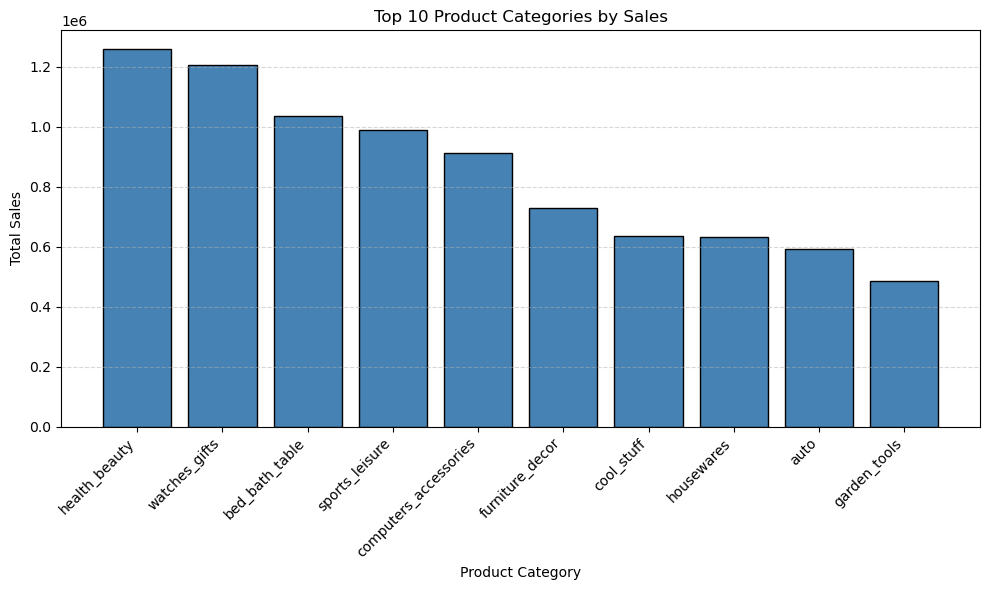

In [22]:
#Barchart
import matplotlib.pyplot as plt

category_sales = (sales_data.groupby("product_category_name_english")["price"].sum() .sort_values(ascending=False))

top_10_categories = category_sales.head(10)

plt.figure(figsize=(10, 6))

plt.bar( top_10_categories.index, top_10_categories.values,color="steelblue",  edgecolor="black")

plt.title("Top 10 Product Categories by Sales")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### 2. What is the distribution of product prices?

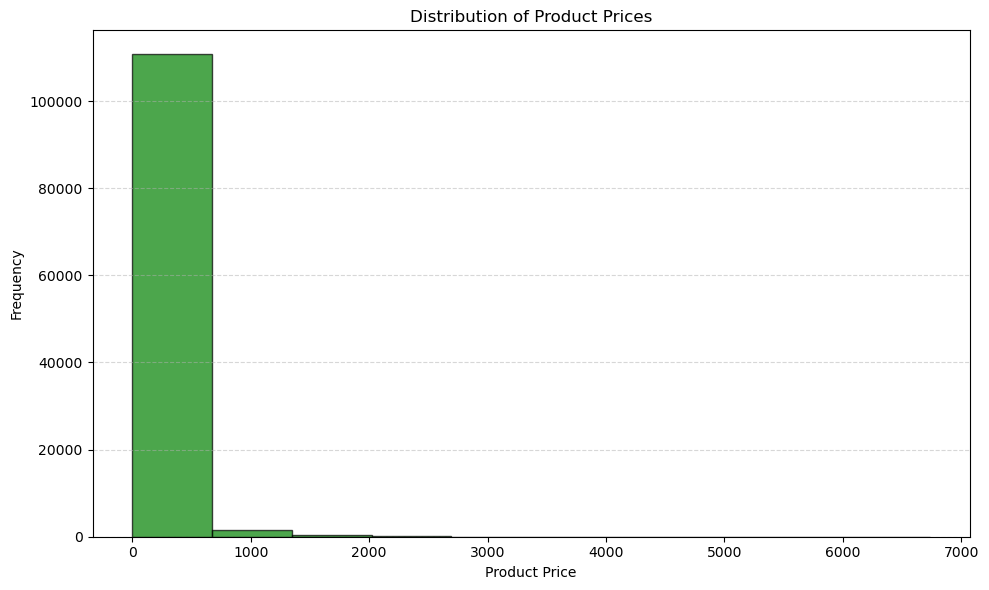

In [27]:
#Histogram

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

#plot histogram with price column, seprate the result into 10 intervals, black color and transparency of 0.7
plt.hist(sales_data["price"], bins=10,color="green",edgecolor="black", alpha=0.7)

plt.title("Distribution of Product Prices")

plt.xlabel("Product Price")

plt.ylabel("Frequency")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 3. How are prices related to freight costs?



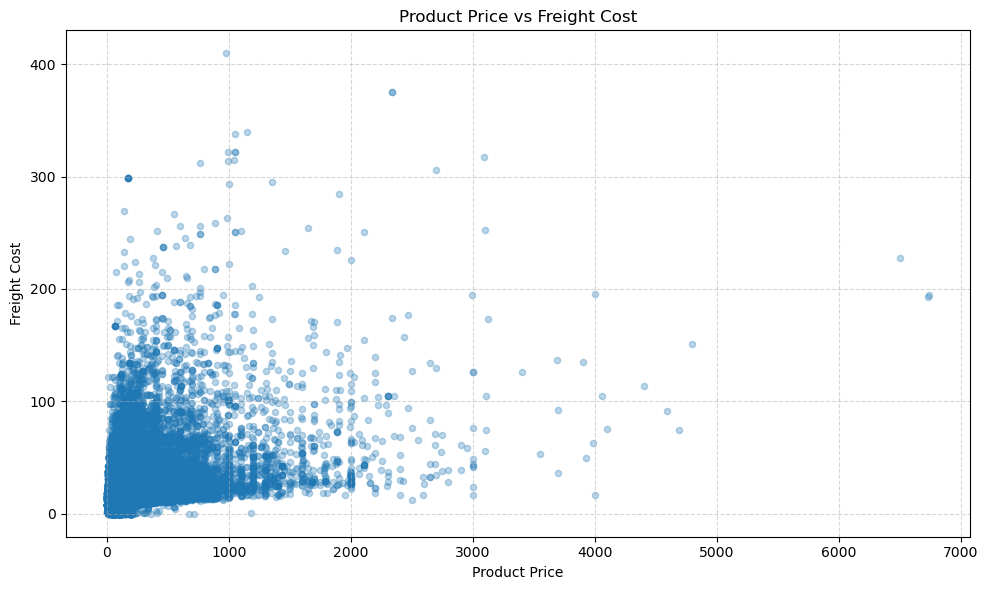

In [28]:
#Scatter plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# plotting using price column and sales_data column
plt.scatter(sales_data["price"], sales_data["freight_value"],alpha=0.3, s=20)

plt.title("Product Price vs Freight Cost")

plt.xlabel("Product Price")

plt.ylabel("Freight Cost")

plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 4. Which Brazilian states have the most orders?

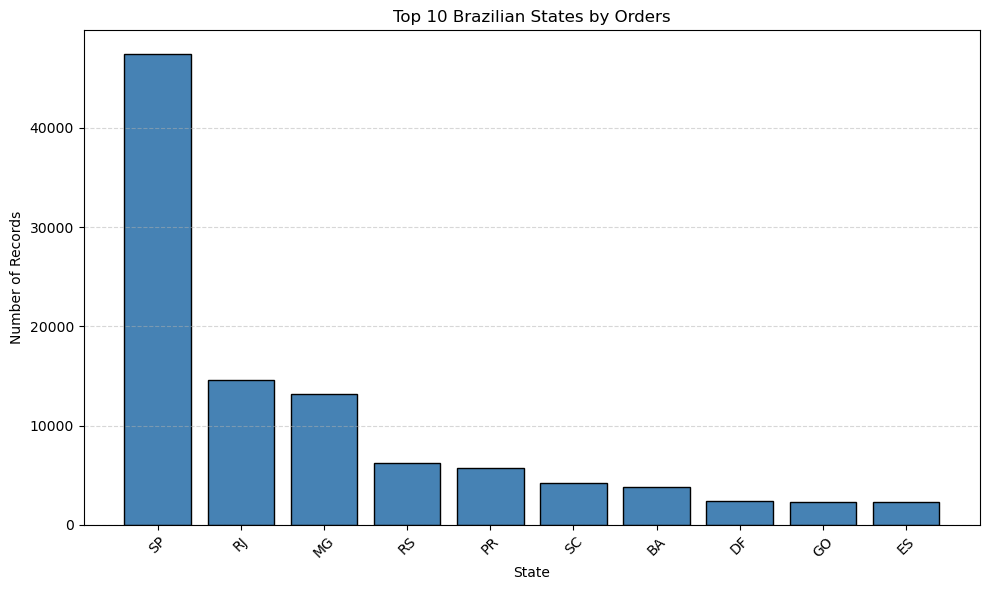

In [31]:
#Bar chart

import matplotlib.pyplot as plt

#created state_orders variable that consist of customer state in the dataframe using value count,(count aggregate for each section) then sort each state from highest to lowest
state_orders = (sales_data["customer_state"] .value_counts() .sort_values(ascending=False))

top_10_states = state_orders.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_10_states.index, top_10_states.values, color="steelblue", edgecolor="black")

plt.title("Top 10 Brazilian States by Orders")

plt.xlabel("State")

plt.ylabel("Number of Records")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 5. How have purchases changed over time?


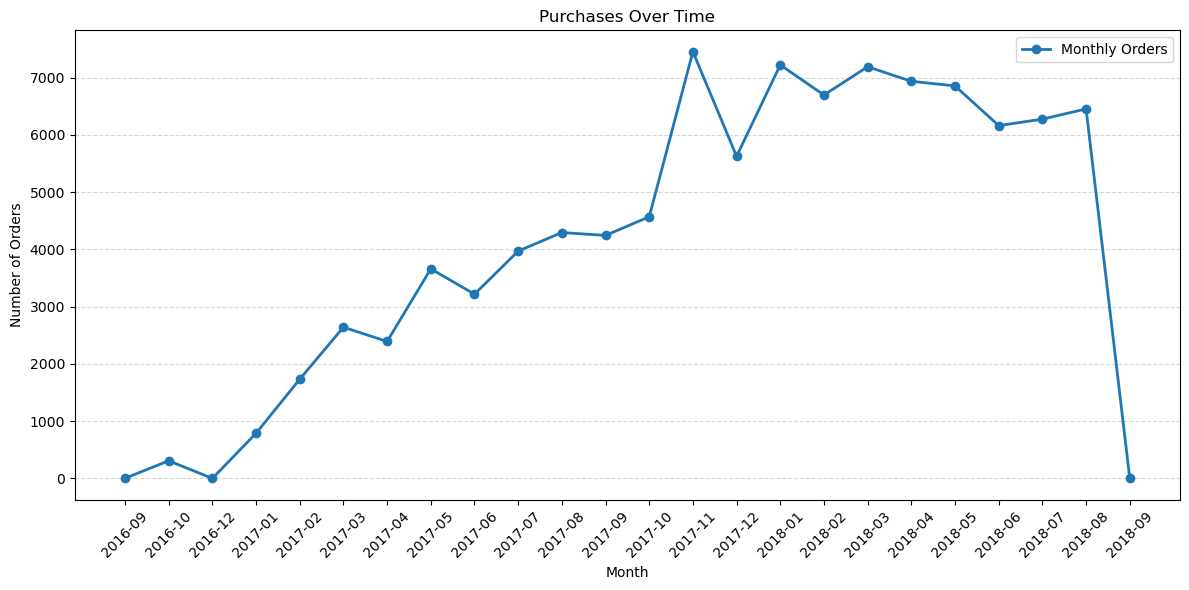

In [33]:
#Line chart

import matplotlib.pyplot as plt
import pandas as pd

#monthly_orders variable was wraaped by grouping timestamp after exrtacting year and month only and group by order_id with unique one only.
monthly_orders = (sales_data.groupby( sales_data["order_purchase_timestamp"].dt.to_period("M") )["order_id"].nunique())

plt.figure(figsize=(12, 6))

plt.plot(monthly_orders.index.astype(str), monthly_orders.values, marker="o", linewidth=2, label="Monthly Orders")

plt.title("Purchases Over Time")

plt.xlabel("Month")

plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()

plt.show()

#### 6. Which order statuses are most common?



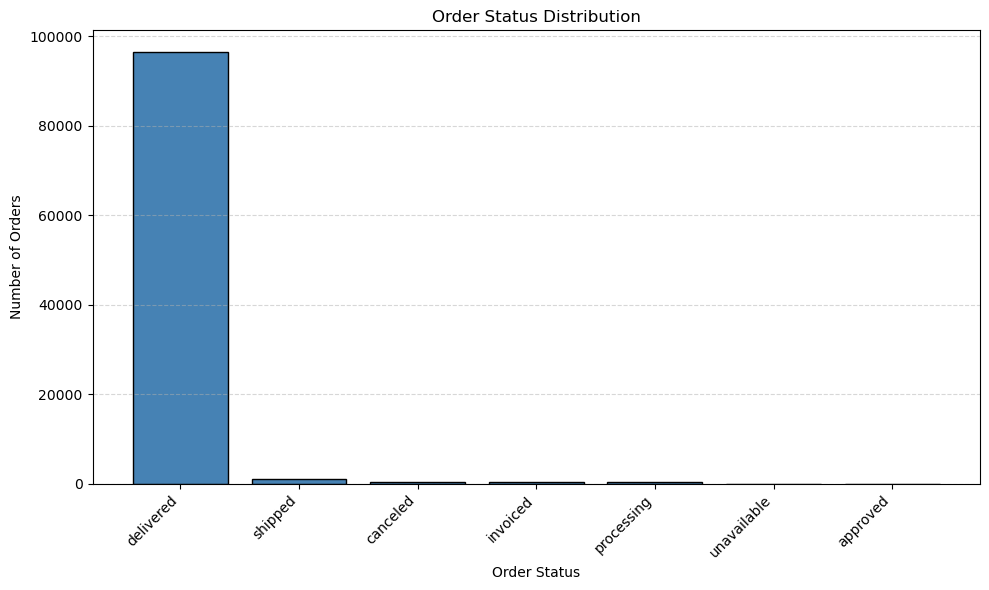

In [35]:
#Barchart

import matplotlib.pyplot as plt

# getting our status_orders through grouping of order_status and unique order_id
status_orders = (sales_data.groupby("order_status")["order_id"].nunique().sort_values(ascending=False))

plt.figure(figsize=(10, 6))

plt.bar(status_orders.index, status_orders.values, color="steelblue", edgecolor="black")

plt.title("Order Status Distribution")

plt.xlabel("Order Status")

plt.ylabel("Number of Orders")

# using xticks coz of the label word are too long,rotation=45 tilts the industry names, while ha="right" aligns them so they are easier to read.
plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

#### 7. How does product price distribution differ across order statuses?

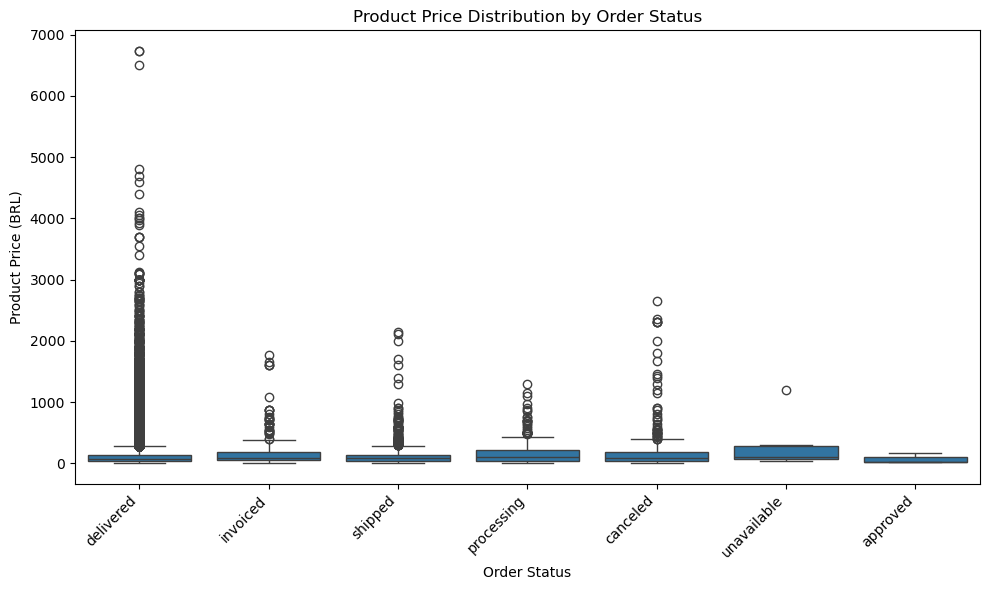

In [8]:
#boxplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot( data=sales_data, x="order_status", y="price")

plt.title("Product Price Distribution by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Product Price (BRL)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

#### 8. How does the relationship between product price and freight cost vary across product categories?

C:\Users\DELL\AppData\Local\Temp\ipykernel_10840\3003405911.py:14: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


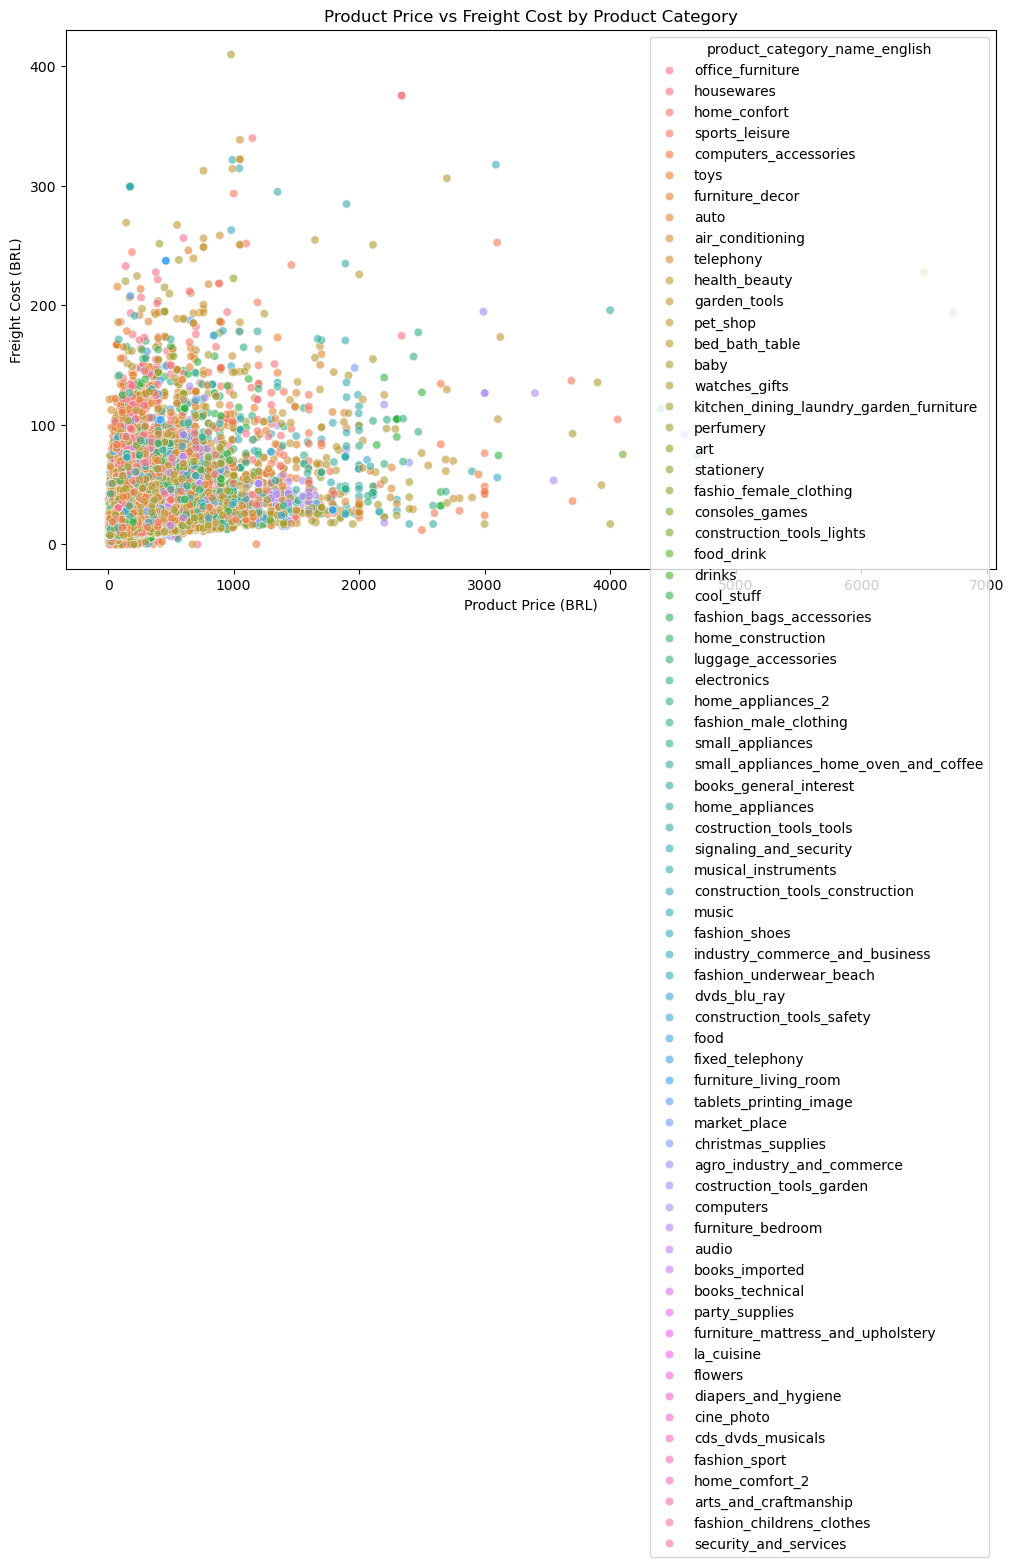

In [10]:
#Scatterplot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.scatterplot(data=sales_data,  x="price", y="freight_value", hue="product_category_name_english", alpha=0.6)

plt.title("Product Price vs Freight Cost by Product Category")
plt.xlabel("Product Price (BRL)")
plt.ylabel("Freight Cost (BRL)")

plt.tight_layout()
plt.show()

## Key Insights

- The business generated a total revenue of **13,591,643.70 BRL** from the analyzed orders.
- A total of **98,666 unique customers** made purchases during the analysis period.
- The **Health & Beauty** category generated the highest revenue (**1,258,681.34 BRL**).
- The **Bed Bath & Table** category recorded the highest sales volume with **11,115 items sold**.
- **São Paulo (SP)** generated the highest revenue among all states (**5,202,955.05 BRL**).
- **São Paulo** was the highest revenue-generating city (**1,914,924.54 BRL**).
- **May** recorded the highest monthly revenue in both the purchase-date and approval-date analyses.
- The **Delivered** status accounted for the majority of orders (**110,197 orders**).
- The average freight cost per order item was **19.99 BRL**.
- The most active customer placed **16 orders**, while the customer with the highest purchase volume bought **24 items**.

## Business Recommendations

- Increase inventory availability for high-performing product categories, particularly **Health & Beauty** and **Bed Bath & Table**, to meet customer demand.
- Monitor sales performance before and during **May** to ensure sufficient stock and operational readiness during the highest revenue period.
- Maintain the operational processes that contributed to the high proportion of successfully delivered orders.
- Analyze purchasing patterns of customers with multiple orders or high purchase volumes to better understand repeat buying behavior.
- Monitor freight costs regularly to ensure shipping charges remain competitive while maintaining profitability.

## Conclusion

The sales performance analysis provides an overview of revenue, customer purchasing behavior, product category performance, geographic sales distribution, monthly sales trends, order fulfillment, and shipping costs. The results identify the business's strongest-performing categories, regions, and sales periods while highlighting the distribution of customer purchasing activity. These insights can support data-driven decision-making in inventory planning, sales monitoring, customer analysis, and operational performance.